# Persiapan Environment & Load Data

In [1]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


In [2]:
# LOAD DATASET
raw = pd.read_csv('/content/dataset_capstone.csv', sep=';')


# Cek Struktur & Konversi Tipe Data

In [3]:
# MEMPERBAIKI FORMAT DATASET
split_data = raw[raw.columns[0]].str.split(',', expand=True)

# Menggunakan nama kolom asli
split_data.columns = raw.columns

# Membuat dataframe final
df = split_data.copy()

In [4]:
# MENAMPILKAN DATA AWAL
print("5 Data Pertama")
print(df.head())

print("\nUkuran Dataset")
print(df.shape)

5 Data Pertama
  Marital status Application mode Application order Course  \
0              1                8                 5      2   
1              1                6                 1     11   
2              1                1                 5      5   
3              1                8                 2     15   
4              2               12                 1      3   

  Daytime/evening attendance Previous qualification Nacionality  \
0                          1                      1           1   
1                          1                      1           1   
2                          1                      1           1   
3                          1                      1           1   
4                          0                      1           1   

  Mother's qualification Father's qualification Mother's occupation  ...  \
0                     13                     10                   6  ...   
1                      1                      3          

In [5]:
# CEK INFORMASI DATA
print("\nInformasi Dataset")
print(df.info())



Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   Marital status                                  4424 non-null   object
 1   Application mode                                4424 non-null   object
 2   Application order                               4424 non-null   object
 3   Course                                          4424 non-null   object
 4   Daytime/evening attendance                      4424 non-null   object
 5   Previous qualification                          4424 non-null   object
 6   Nacionality                                     4424 non-null   object
 7   Mother's qualification                          4424 non-null   object
 8   Father's qualification                          4424 non-null   object
 9   Mother's occupation              

In [6]:
# KONVERSI DATA NUMERIK
for col in df.columns[:-1]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nTipe Data Setelah Konversi")
print(df.info())


Tipe Data Setelah Konversi
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occu

# Handling Missing Values & Duplikasi

In [7]:
# CEK MISSING VALUES
print("\nJumlah Missing Values")
print(df.isnull().sum())


Jumlah Missing Values
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                            

In [8]:
# MENANGANI MISSING VALUES
df = df.fillna(df.median(numeric_only=True))

print("\nTotal Missing Values Setelah Cleaning")
print(df.isnull().sum().sum())


Total Missing Values Setelah Cleaning
0


In [9]:
# MENGHAPUS DATA DUPLIKAT
print("\nJumlah Data Sebelum Hapus Duplikat")
print(df.shape)

df = df.drop_duplicates()

print("\nJumlah Data Setelah Hapus Duplikat")
print(df.shape)


Jumlah Data Sebelum Hapus Duplikat
(4424, 35)

Jumlah Data Setelah Hapus Duplikat
(4424, 35)


# Visualisasi Distribusi Target & Pemisahan Feature Target

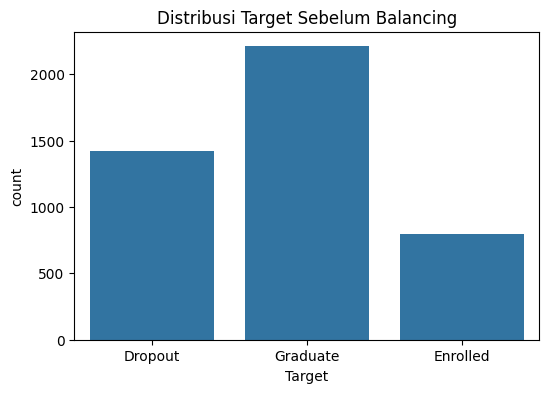


Jumlah Kelas Target
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [10]:
# VISUALISASI DISTRIBUSI TARGET
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df)

plt.title('Distribusi Target Sebelum Balancing')
plt.show()

print("\nJumlah Kelas Target")
print(df['Target'].value_counts())

In [11]:
# MEMISAHKAN FEATURE DAN TARGET
X = df.drop(columns=['Target'])
y = df['Target']

# Encode target menjadi numerik
y = y.astype('category').cat.codes


# Balancing Data (SMOTE) & Scaling

In [12]:
# BALANCING DATA DENGAN SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nJumlah Data Sebelum SMOTE")
print(X.shape)

print("\nJumlah Data Setelah SMOTE")
print(X_resampled.shape)


Jumlah Data Sebelum SMOTE
(4424, 34)

Jumlah Data Setelah SMOTE
(6627, 34)


In [13]:
# MEMBUAT DATAFRAME BALANCED
balanced_df = pd.DataFrame(X_resampled, columns=X.columns)
balanced_df['Target'] = y_resampled

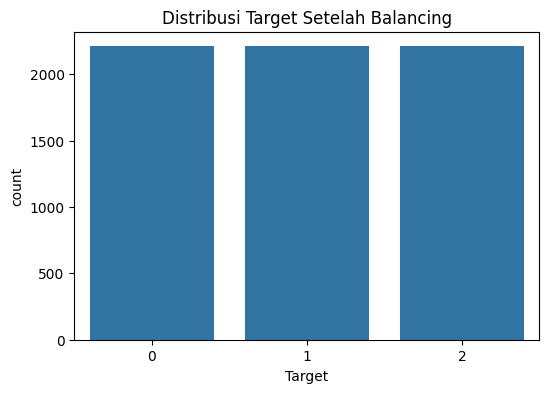

In [14]:
# VISUALISASI SETELAH BALANCING
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=balanced_df)

plt.title('Distribusi Target Setelah Balancing')
plt.show()

In [15]:
# FEATURE SCALING
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_resampled)

print("\nUkuran Data Setelah Scaling")
print(X_scaled.shape)

# SPLIT DATA TRAIN & TEST
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_resampled,
    test_size=0.2, #80:20
    random_state=42,
    stratify=y_resampled
)

print("\nUkuran X_train :", X_train.shape)
print("Ukuran X_test  :", X_test.shape)



Ukuran Data Setelah Scaling
(6627, 34)

Ukuran X_train : (5301, 34)
Ukuran X_test  : (1326, 34)


In [16]:
# SIMPAN DATASET HASIL PREPROCESSING
balanced_df.to_csv('/content/dataset_balanced.csv', index=False)

print("\nPreprocessing selesai.")
print("Dataset berhasil disimpan sebagai dataset_balanced.csv")


Preprocessing selesai.
Dataset berhasil disimpan sebagai dataset_balanced.csv
